In [1]:
import pandas as pd
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load data
weather_df = pd.read_csv("weather_data_30k_points.csv")
fire_df = pd.read_csv("viirs_firepoints_aus_nov2019_feb2020.csv")

# -------------------------------
# 2. Extract Coordinates from '.geo'
# -------------------------------
def extract_coordinates(geo_json_str):
    try:
        geo = json.loads(geo_json_str)
        coords = geo['coordinates']
        return coords[0], coords[1]  # lon, lat
    except:
        return None, None

fire_df['lon'], fire_df['lat'] = zip(*fire_df['.geo'].map(extract_coordinates))
fire_df['date'] = pd.to_datetime(fire_df['date'])
weather_df['date'] = pd.to_datetime(weather_df['date'])

# -------------------------------
# 3. Label Weather Data with Fire Occurrences
# -------------------------------
weather_df['lat_round'] = weather_df['latitude'].round(2)
weather_df['lon_round'] = weather_df['longitude'].round(2)
fire_df['lat_round'] = fire_df['lat'].round(2)
fire_df['lon_round'] = fire_df['lon'].round(2)

# Filter relevant date range
date_range = (weather_df['date'].min(), weather_df['date'].max())
filtered_fire_df = fire_df[(fire_df['date'] >= date_range[0]) & (fire_df['date'] <= date_range[1])].dropna(subset=['lat', 'lon'])

# Merge and label
merged = pd.merge(
    weather_df,
    filtered_fire_df[['date', 'lat_round', 'lon_round']],
    how='left',
    on=['date', 'lat_round', 'lon_round'],
    indicator=True
)
merged['fire'] = merged['_merge'].apply(lambda x: 1 if x == 'both' else 0)
merged.drop(columns=['_merge', 'lat_round', 'lon_round'], inplace=True)

# -------------------------------
# 4. Build and Train Fire Prediction Model
# -------------------------------
# Features
features = [
    'air_tmax', 'air_tmin', 'radiation', 'rainfall', 'rh_tmax', 'rh_tmin',
    'vp', 'vp_deficit', 'evap_pan', 'evap_syn', 'evap_comb', 'evap_morton_lake'
]

# Split data for training
fire_yes = merged[merged['fire'] == 1]
fire_no = merged[merged['fire'] == 0].sample(n=len(fire_yes)*4, random_state=42)
balanced_df = pd.concat([fire_yes, fire_no])
X = balanced_df[features]
y = balanced_df['fire']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train baseline model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
print("Baseline Results")
print(classification_report(y_test, clf.predict(X_test)))

# -------------------------------
# 5. Manual Oversampling for Improved Performance
# -------------------------------
fire_yes_oversampled = pd.concat([fire_yes]*10, ignore_index=True)
fire_no_sampled = fire_no
oversampled_df = pd.concat([fire_yes_oversampled, fire_no_sampled], ignore_index=True)

X_over = oversampled_df[features]
y_over = oversampled_df['fire']
X_train_over, X_test_over, y_train_over, y_test_over = train_test_split(X_over, y_over, stratify=y_over, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_over, y_train_over)
print("Oversampled Model Results")
print(classification_report(y_test_over, rf_model.predict(X_test_over)))

Baseline Results
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        35
           1       0.25      0.11      0.15         9

    accuracy                           0.75        44
   macro avg       0.53      0.51      0.50        44
weighted avg       0.69      0.75      0.71        44

Oversampled Model Results
              precision    recall  f1-score   support

           0       1.00      0.71      0.83        35
           1       0.90      1.00      0.95        89

    accuracy                           0.92       124
   macro avg       0.95      0.86      0.89       124
weighted avg       0.93      0.92      0.91       124



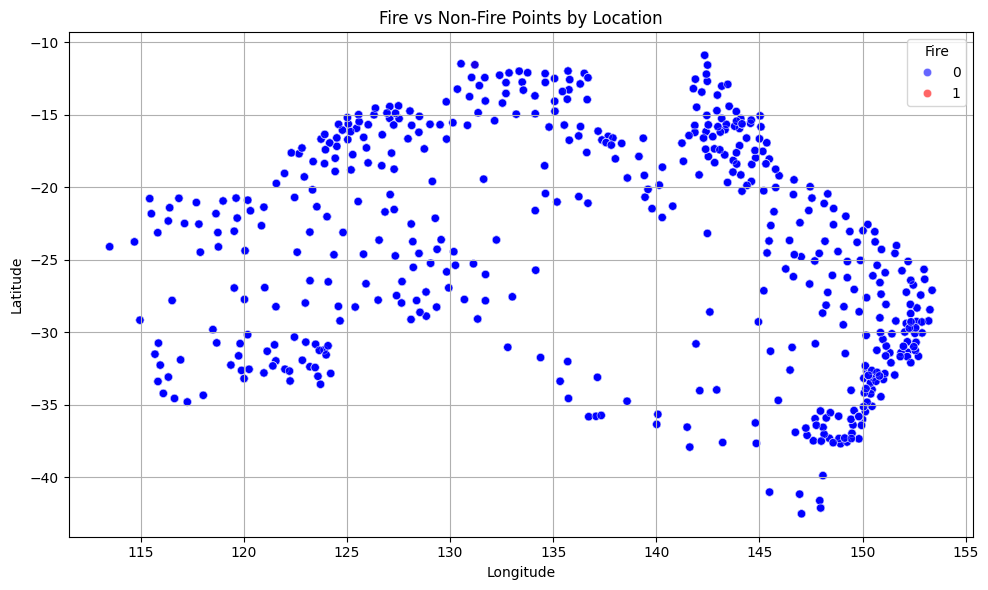

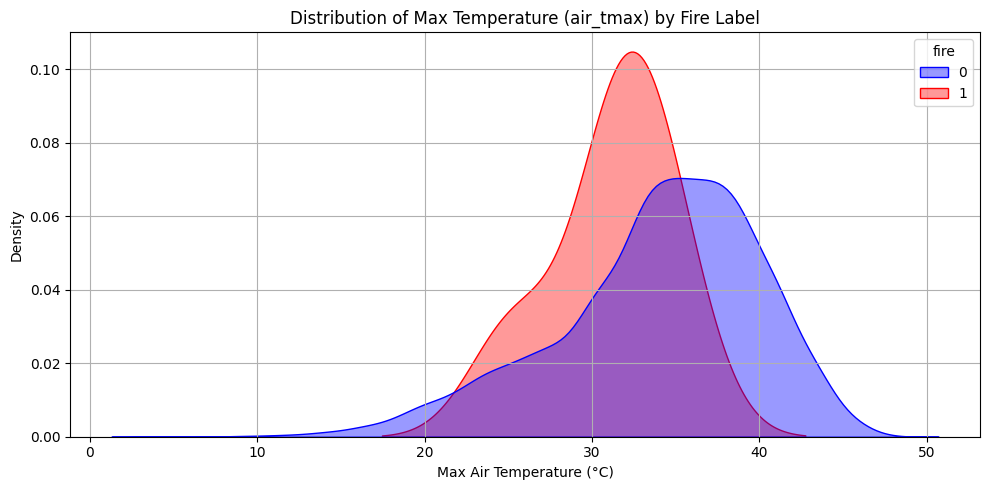

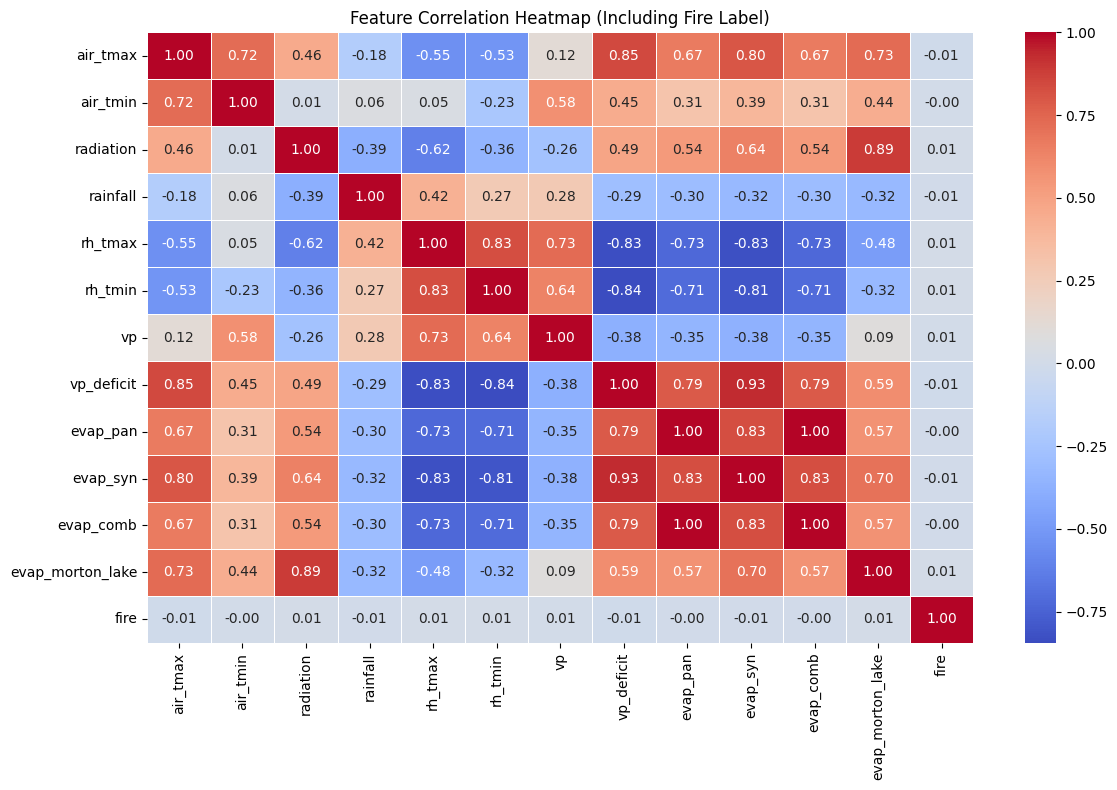

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample for visualization (due to size)
sample_df = merged.sample(n=10000, random_state=42)

# 1. Fire points on map (scatterplot of lat/lon)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='longitude', y='latitude', hue='fire', alpha=0.6, palette={0: 'blue', 1: 'red'})
plt.title("Fire vs Non-Fire Points by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Fire")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Distribution of air_tmax for fire vs non-fire
plt.figure(figsize=(10, 5))
sns.kdeplot(data=sample_df, x='air_tmax', hue='fire', fill=True, common_norm=False, alpha=0.4, palette={0: 'blue', 1: 'red'})
plt.title("Distribution of Max Temperature (air_tmax) by Fire Label")
plt.xlabel("Max Air Temperature (°C)")
plt.ylabel("Density")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Correlation heatmap of features
plt.figure(figsize=(12, 8))
corr = sample_df[features + ['fire']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Including Fire Label)")
plt.tight_layout()
plt.show()
